# NorthBay Living — Feature Engineering & Seasonal-Naive Baseline (v2 dataset)

Continues from `data_cleaning_v2.ipynb` and `eda_v2.ipynb`. Same method, same tables kept
separate on disk, only joined in memory when a question needs it.

Per the engagement brief (Section 07), the correct order is: **frame the metric first,
build the baseline second, engineer features third** — the baseline is the bar every
later model has to clear, and it doesn't need engineered features to exist. This notebook
follows that order:

1. Load data and build a **weekly, per (store, product) demand panel** — the brief asks for
   a *weekly* SKU-level forecast, so daily rows are aggregated to weeks first.
2. **Frame the metric**: define WAPE (primary), MAPE and bias (secondary), and fix the
   forecast horizon.
3. **Build the seasonal-naive baseline** and score it with WAPE on a held-out horizon.
4. **Engineer features** (lags, rolling stats, calendar/promo/epidemic signals) for the
   real model in the next notebook — built now (matching the Week-2, Day-9 timeline) but
   not used by the baseline itself.
5. Save both outputs (`weekly_panel_features.csv`, `baseline_backtest.csv`) for
   `04_model.ipynb`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
print("Libraries loaded.")


Libraries loaded.


## Step 1 — Load the cleaned tables

Loading the four source tables (not `sales_data`, which is just a merged convenience view —
we keep working from the separate cleaned tables, same as the EDA notebook).

In [2]:
sales = pd.read_csv('../Cleaned + Splitted/sales_daily_cleaned_v2.csv', parse_dates=['date'])
inventory = pd.read_csv('../Cleaned + Splitted/inventory_snapshots_cleaned_v2.csv', parse_dates=['date'])
sku = pd.read_csv('../Cleaned + Splitted/sku_master_cleaned_v2.csv')
calendar = pd.read_csv('../Cleaned + Splitted/calender_cleaned_v2.csv', parse_dates=['date'])

for name, df in [('sales', sales), ('inventory', inventory), ('sku', sku), ('calendar', calendar)]:
    print(f"{name:10s} {df.shape}  date range: {df['date'].min() if 'date' in df else '-'} .. {df['date'].max() if 'date' in df else '-'}")


sales      (76000, 8)  date range: 2022-01-01 00:00:00 .. 2024-01-30 00:00:00
inventory  (76000, 6)  date range: 2022-01-01 00:00:00 .. 2024-01-30 00:00:00
sku        (100, 4)  date range: - .. -
calendar   (760, 12)  date range: 2022-01-01 00:00:00 .. 2024-01-30 00:00:00


## Step 2 — Build the weekly demand panel

The brief asks for a **weekly, SKU-level** forecast, and `sku_master` in this dataset is keyed
by `(store_id, product_id)` — category isn't a pure product attribute here (documented in
`data_cleaning_v2.ipynb`). So the forecasting grain is **one row per (store_id, product_id,
week)**.

Weeks are built with pandas' own `to_period('W')` (Monday-start, Sunday-end) rather than the
`weekofyear` column in `calendar`, because `weekofyear` resets every January and would make a
week in late December 2022 and a week in early January 2023 look unrelated when they're really
the same 7-day block split by the calendar table's own numbering. `to_period('W')` gives a
continuous, unambiguous week index across the full 2-year history.

**Target = `units_sold`** (actual units sold), not the `demand` column. `demand` is an
estimate (confirmed in cleaning: ~25% of rows have `units_sold > demand`, so it's not a hard
ceiling) — it's a *candidate benchmark forecast*, not a ground-truth label. In a real client
engagement you'd only ever have actuals to train on, so we train against `units_sold`, and we
keep `demand` around as an optional second baseline to compare against in `04_model.ipynb`.

In [3]:
daily = sales.merge(calendar[['date', 'year', 'month', 'quarter', 'seasonality', 'epidemic']], on='date', how='left')

daily['week'] = daily['date'].dt.to_period('W').apply(lambda r: r.start_time)

weekly = (
    daily.groupby(['store_id', 'product_id', 'week'])
    .agg(
        units_sold=('units_sold', 'sum'),
        demand=('demand', 'sum'),
        price=('price', 'mean'),
        discount=('discount', 'mean'),
        promotion_share=('promotion', 'mean'),
        epidemic_share=('epidemic', 'mean'),
        n_days=('date', 'count'),
    )
    .reset_index()
    .sort_values(['store_id', 'product_id', 'week'])
)

print("Weekly panel shape:", weekly.shape)
weekly.head()


Weekly panel shape: (11000, 10)


,store_id,product_id,week,units_sold,demand,price,discount,promotion_share,epidemic_share,n_days
0,S001,P0001,2021-12-27,173,199,69.175000,5.000000,0.000000,0.0,2
1,S001,P0001,2022-01-03,656,742,67.312857,11.428571,0.428571,0.0,7
2,S001,P0001,2022-01-10,582,717,67.694286,8.571429,0.285714,0.0,7
3,S001,P0001,2022-01-17,585,670,66.600000,10.714286,0.285714,0.0,7
4,S001,P0001,2022-01-24,667,706,65.115714,13.571429,0.428571,0.0,7


**Drop incomplete weeks.** The first and last week of the 2-year window can have fewer
than 7 days of history (the data starts/ends mid-week), which would understate `units_sold`
for that week and bias both the baseline and any model. We drop any (store, product, week)
group with `n_days < 7`.

In [4]:
before = len(weekly)
incomplete = weekly[weekly['n_days'] < 7]
print(f"Incomplete weeks found: {len(incomplete)} ({len(incomplete)/before*100:.2f}% of rows)")
print("Weeks affected:", sorted(incomplete['week'].dt.date.unique()))

weekly = weekly[weekly['n_days'] == 7].drop(columns='n_days').reset_index(drop=True)
print("Weekly panel shape after dropping incomplete weeks:", weekly.shape)


Incomplete weeks found: 200 (1.82% of rows)
Weeks affected: [datetime.date(2021, 12, 27), datetime.date(2024, 1, 29)]
Weekly panel shape after dropping incomplete weeks: (10800, 9)


In [5]:
# Attach static SKU attributes and a per-week season/month label (from calendar, first day of week)
weekly = weekly.merge(sku, on=['store_id', 'product_id'], how='left')

week_calendar = (
    calendar.assign(week=calendar['date'].dt.to_period('W').apply(lambda r: r.start_time))
    .groupby('week')
    .agg(month=('month', 'first'), quarter=('quarter', 'first'), seasonality=('seasonality', 'first'))
    .reset_index()
)
weekly = weekly.merge(week_calendar, on='week', how='left')

assert weekly[['category', 'region', 'month', 'quarter', 'seasonality']].isnull().sum().sum() == 0, "Unexpected nulls after merge"
print("Panel with SKU + calendar attributes:", weekly.shape)
weekly.head()


Panel with SKU + calendar attributes: (10800, 14)


,store_id,product_id,week,units_sold,demand,price,discount,promotion_share,epidemic_share,category,region,month,quarter,seasonality
0,S001,P0001,2022-01-03,656,742,67.312857,11.428571,0.428571,0.0,Electronics,North,1,1,Winter
1,S001,P0001,2022-01-10,582,717,67.694286,8.571429,0.285714,0.0,Electronics,North,1,1,Winter
2,S001,P0001,2022-01-17,585,670,66.600000,10.714286,0.285714,0.0,Electronics,North,1,1,Winter
3,S001,P0001,2022-01-24,667,706,65.115714,13.571429,0.428571,0.0,Electronics,North,1,1,Winter
4,S001,P0001,2022-01-31,562,624,67.007143,7.857143,0.285714,0.0,Electronics,North,1,1,Winter


**Sanity check — full grid, no gaps.** Every (store, product) pair should have the same
number of consecutive weekly rows; a missing week for one SKU-store but not others would mean
a silent hole in the panel that later `.shift()`/`.rolling()` calls would mis-align.

In [6]:
counts = weekly.groupby(['store_id', 'product_id'])['week'].count()
print("Weeks per (store, product):", counts.min(), "to", counts.max(), " | unique combos:", counts.shape[0])
assert counts.min() == counts.max(), "Panel is not a complete, regular grid — investigate before building lag features"
print("Confirmed: every (store, product) has the same number of consecutive weeks — safe to shift/roll per group.")


Weeks per (store, product): 108 to 108  | unique combos: 100
Confirmed: every (store, product) has the same number of consecutive weeks — safe to shift/roll per group.


## Step 3 — Frame the metric (before building anything)

Per the brief's non-negotiable rule: fix how success is measured *before* touching a model,
and never let a metric choice get tuned after the fact to flatter a result.

- **WAPE** (primary) — `sum(|actual - forecast|) / sum(actual)`, per Appendix B. Robust to the
  low-volume SKU-weeks where MAPE explodes (division by a near-zero actual).
- **MAPE** (secondary, informational only) — reported but expected to be unstable on any
  week with very low actual sales.
- **Bias** (secondary) — signed mean error (`forecast - actual`); positive = over-forecasting,
  negative = under-forecasting. Checked, not optimized against.

**Horizon**: 6 weeks, the low end of the brief's suggested 6–8 week range. Chosen deliberately
short — this dataset only spans ~2 years (~104 weekly periods per SKU-store), and the seasonal
baseline below needs a full prior year of history before it can produce a forecast at all. A
short holdout leaves the maximum history available for that lag-52 lookup and for engineered
features in the next notebook.

In [7]:
def wape(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    return np.abs(actual - forecast).sum() / actual.sum()

def mape(actual, forecast, eps=1e-9):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    return np.mean(np.abs(actual - forecast) / np.clip(actual, eps, None))

def bias(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    return np.mean(forecast - actual)

HORIZON_WEEKS = 6
all_weeks = np.sort(weekly['week'].unique())
holdout_weeks = all_weeks[-HORIZON_WEEKS:]
train_weeks = all_weeks[:-HORIZON_WEEKS]

print(f"Total weeks in panel: {len(all_weeks)}")
print(f"Training history:     {train_weeks[0].astype('datetime64[D]')} .. {train_weeks[-1].astype('datetime64[D]')}  ({len(train_weeks)} weeks)")
print(f"Holdout (forecast horizon): {holdout_weeks[0].astype('datetime64[D]')} .. {holdout_weeks[-1].astype('datetime64[D]')}  ({len(holdout_weeks)} weeks)")


Total weeks in panel: 108
Training history:     2022-01-03 .. 2023-12-11  (102 weeks)
Holdout (forecast horizon): 2023-12-18 .. 2024-01-22  (6 weeks)


## Step 4 — Seasonal-naive baseline

Forecast for a given (store, product, week) = the actual `units_sold` for that same
(store, product) **52 weeks earlier** (same week, one year prior). This is the standard
seasonal-naive definition for weekly data with annual seasonality, and matches the dashed
baseline line in the brief's Figure 5.

Built with a plain per-group `shift(52)` on the sorted weekly panel — no model, no fitting,
just a lookup. If a lag-52 value isn't available (only possible for early weeks in year 1,
which aren't in our holdout anyway), we fall back to lag-1 (last observed week) and flag it.

In [8]:
weekly = weekly.sort_values(['store_id', 'product_id', 'week']).reset_index(drop=True)

weekly['naive_seasonal_lag52'] = (
    weekly.groupby(['store_id', 'product_id'])['units_sold'].shift(52)
)
weekly['naive_lag1'] = (
    weekly.groupby(['store_id', 'product_id'])['units_sold'].shift(1)
)

weekly['baseline_forecast'] = weekly['naive_seasonal_lag52']
weekly['baseline_used_fallback'] = weekly['baseline_forecast'].isna() & weekly['naive_lag1'].notna()
weekly['baseline_forecast'] = weekly['baseline_forecast'].fillna(weekly['naive_lag1'])

print("Rows with no seasonal (lag-52) value available:", weekly['naive_seasonal_lag52'].isna().sum(),
      f"out of {len(weekly)} — all in year 1, expected.")
print("Fallback (lag-1) used instead:", weekly['baseline_used_fallback'].sum(), "rows")


Rows with no seasonal (lag-52) value available: 5200 out of 10800 — all in year 1, expected.
Fallback (lag-1) used instead: 5100 rows


In [9]:
holdout = weekly[weekly['week'].isin(holdout_weeks)].copy()
print("Holdout rows:", len(holdout), " | SKU-stores:", holdout[['store_id','product_id']].drop_duplicates().shape[0])

missing_baseline = holdout['baseline_forecast'].isna().sum()
print("Holdout rows missing a baseline forecast:", missing_baseline)
assert missing_baseline == 0, "Every holdout row must have a baseline forecast before scoring — check the fallback logic above."


Holdout rows: 600  | SKU-stores: 100
Holdout rows missing a baseline forecast: 0


In [10]:
overall_wape = wape(holdout['units_sold'], holdout['baseline_forecast'])
overall_mape = mape(holdout['units_sold'], holdout['baseline_forecast'])
overall_bias = bias(holdout['units_sold'], holdout['baseline_forecast'])

print(f"Seasonal-naive baseline — holdout ({HORIZON_WEEKS} weeks, {len(holdout)} SKU-store-weeks)")
print(f"  WAPE: {overall_wape:.3f}  ({overall_wape*100:.1f}%)")
print(f"  MAPE: {overall_mape:.3f}  ({overall_mape*100:.1f}%)  [informational — unstable on low-volume weeks]")
print(f"  Bias: {overall_bias:+.2f} units/week  ({'over-forecasting' if overall_bias>0 else 'under-forecasting'} on average)")


Seasonal-naive baseline — holdout (6 weeks, 600 SKU-store-weeks)
  WAPE: 0.282  (28.2%)
  MAPE: 0.391  (39.1%)  [informational — unstable on low-volume weeks]
  Bias: +86.68 units/week  (over-forecasting on average)


**Why the bias is positive — a real, explainable finding, not a bug.** The holdout falls in
late Dec 2023 / early Jan 2024, which overlaps an epidemic period; the same calendar weeks one
year earlier (the baseline's lookup source) did not. Checking `epidemic_share` for both:

| Week | This year (holdout) | Same week last year (baseline source) |
|---|---|---|
| 2023-12-25 / 2022-12-26 | 0.71 | 0.00 |
| 2024-01-01 / 2023-01-02 | 1.00 | 0.00 |

The seasonal-naive baseline has no way to know this year's holiday weeks were hit by the
epidemic — it just replays last year's (epidemic-free) sales, so it systematically
over-forecasts. This is exactly the EDA's top finding (epidemic ≈ biggest driver, ~30% drop in
sales) showing up again here, and it's precisely why `epidemic_share_lag1` and the calendar
features were built above: a model that knows about the epidemic period should beat this
baseline by a wide margin, not just a marginal one.

**Double-check — is the shift actually aligned correctly?** Before trusting this number,
spot-check one SKU-store by hand: its `baseline_forecast` in the holdout should equal its own
`units_sold` from exactly 52 weeks earlier, not a neighboring row or a different SKU.

In [11]:
check_store, check_product = weekly.iloc[0][['store_id', 'product_id']]
one_sku = weekly[(weekly['store_id'] == check_store) & (weekly['product_id'] == check_product)].reset_index(drop=True)

sample_idx = one_sku.index[one_sku['week'].isin(holdout_weeks)][0]
target_week = one_sku.loc[sample_idx, 'week']
lookup_week = target_week - pd.Timedelta(weeks=52)

manual_lookup = one_sku.loc[one_sku['week'] == lookup_week, 'units_sold']
print(f"SKU {check_store}/{check_product} — forecasting week {target_week.date()}")
print(f"  Panel's baseline_forecast for this row: {one_sku.loc[sample_idx, 'baseline_forecast']}")
print(f"  Manually looked-up units_sold from {lookup_week.date()} (52 weeks earlier): {manual_lookup.values}")
assert one_sku.loc[sample_idx, 'baseline_forecast'] == manual_lookup.values[0], "Shift alignment is wrong — do not trust WAPE above until fixed"
print("  Match confirmed — shift(52) is correctly aligned per (store, product) group.")


SKU S001/P0001 — forecasting week 2023-12-18


  Panel's baseline_forecast for this row: 670.0
  Manually looked-up units_sold from 2022-12-19 (52 weeks earlier): [670]
  Match confirmed — shift(52) is correctly aligned per (store, product) group.


**Double-check — no future leakage in the baseline itself.** The seasonal-naive forecast
for any holdout week must only reference data from *before* that week. Confirming every
`baseline_forecast` value in the holdout was sourced from a week strictly earlier than the
week being forecast (by construction it's exactly 52 or 1 weeks earlier, both in the past —
this check just proves it programmatically rather than trusting the construction).

In [12]:
lookup_weeks_used = holdout['week'] - pd.to_timedelta(np.where(holdout['baseline_used_fallback'], 1, 52), unit='W')
assert (lookup_weeks_used < holdout['week']).all(), "Found a baseline value sourced from the same week or the future"
print("Confirmed: every holdout baseline forecast is sourced strictly from the past.")


Confirmed: every holdout baseline forecast is sourced strictly from the past.


**Per-category breakdown.** WAPE overall can hide a baseline that's great for stable
categories and terrible for volatile ones — worth checking since the risk-scoring layer will
be built per SKU, not on an aggregate number.

Seasonal-naive WAPE by category:
category
Toys           0.439
Furniture      0.349
Electronics    0.293
Groceries      0.269
Clothing       0.172
dtype: float64


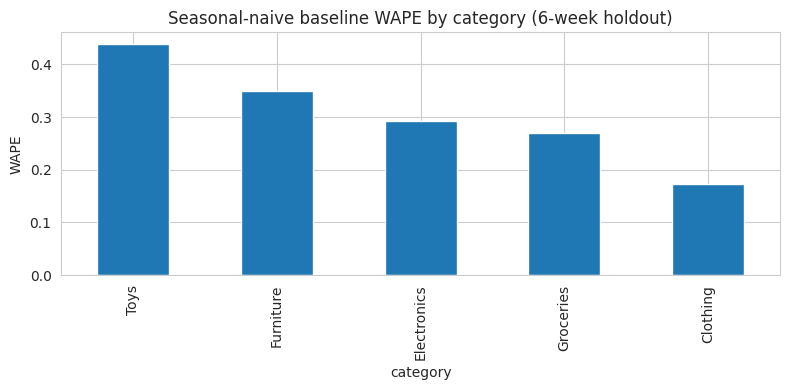

In [13]:
cat_wape = (
    holdout.groupby('category')
    .apply(lambda g: wape(g['units_sold'], g['baseline_forecast']))
    .sort_values(ascending=False)
)
print("Seasonal-naive WAPE by category:")
print(cat_wape.round(3))

plt.figure(figsize=(8, 4))
cat_wape.plot(kind='bar')
plt.ylabel('WAPE')
plt.title(f'Seasonal-naive baseline WAPE by category ({HORIZON_WEEKS}-week holdout)')
plt.tight_layout()
plt.show()


## Step 5 — Feature engineering (for the real model, next notebook)

The baseline above needed no features. The features below are built now — per the Week-2
timeline — so `04_model.ipynb` can start training immediately. **None of this is used by the
baseline; it exists purely to prepare for beating it.**

**Leakage rule applied throughout:** every feature derived *from past sales* (lags, rolling
statistics) is built with `shift(1)` before any `rolling()` call, so the value for week *t*
never includes week *t*'s own `units_sold`. Calendar features (month, quarter, seasonality,
epidemic) are the exception — those describe the week being forecast, not history, and are
legitimately known in advance (NorthBay knows next month is December before it happens). We
flag price/discount/promotion the same way below, since whether "planned promotion for the
forecast week" is fair game depends on whether NorthBay commits to a promo calendar in
advance — treated as an open assumption to confirm with the client, not resolved silently.

In [14]:
g = weekly.groupby(['store_id', 'product_id'])['units_sold']

for lag in [1, 2, 4, 52]:
    weekly[f'lag_{lag}'] = g.shift(lag)

# Rolling stats computed on the *shifted* series so week t's own value can never leak into its own feature
shifted = g.shift(1)
weekly['roll_mean_4'] = shifted.groupby([weekly['store_id'], weekly['product_id']]).transform(lambda s: s.rolling(4, min_periods=2).mean())
weekly['roll_mean_8'] = shifted.groupby([weekly['store_id'], weekly['product_id']]).transform(lambda s: s.rolling(8, min_periods=4).mean())
weekly['roll_std_4']  = shifted.groupby([weekly['store_id'], weekly['product_id']]).transform(lambda s: s.rolling(4, min_periods=2).std())

print("Lag/rolling features added:", [c for c in weekly.columns if c.startswith(('lag_', 'roll_'))])
weekly[['store_id','product_id','week','units_sold','lag_1','lag_2','lag_4','lag_52','roll_mean_4','roll_mean_8']].tail(8)


Lag/rolling features added: ['lag_1', 'lag_2', 'lag_4', 'lag_52', 'roll_mean_4', 'roll_mean_8', 'roll_std_4']


,store_id,product_id,week,units_sold,lag_1,lag_2,lag_4,lag_52,roll_mean_4,roll_mean_8
10792,S005,P0020,2023-12-04,450,462.0,567.0,608.0,577.0,535.75,438.000
10793,S005,P0020,2023-12-11,564,450.0,462.0,506.0,765.0,496.25,470.250
10794,S005,P0020,2023-12-18,638,564.0,450.0,567.0,707.0,510.75,517.500
10795,S005,P0020,2023-12-25,247,638.0,564.0,462.0,787.0,528.50,533.000
10796,S005,P0020,2024-01-01,252,247.0,638.0,450.0,523.0,474.75,505.250
10797,S005,P0020,2024-01-08,531,252.0,247.0,564.0,538.0,425.25,460.750
10798,S005,P0020,2024-01-15,545,531.0,252.0,638.0,610.0,417.00,463.875
10799,S005,P0020,2024-01-22,573,545.0,531.0,247.0,623.0,393.75,461.125


In [15]:
# Calendar features for the *forecast* week — known in advance, not leakage
weekly['month_sin'] = np.sin(2 * np.pi * weekly['month'] / 12)
weekly['month_cos'] = np.cos(2 * np.pi * weekly['month'] / 12)
# epidemic_share for the forecast week itself is NOT known in advance in reality (it's realized, not planned) —
# use the lagged value (last observed week's epidemic exposure) as the safe, non-leaky default feature.
weekly['epidemic_share_lag1'] = weekly.groupby(['store_id', 'product_id'])['epidemic_share'].shift(1)

# Promo/discount: current-week values are only fair if NorthBay commits to a promo calendar in advance.
# We provide BOTH, clearly labelled, and default to the lagged (safe) versions unless that assumption is confirmed.
weekly['promotion_share_lag1'] = weekly.groupby(['store_id', 'product_id'])['promotion_share'].shift(1)
weekly['discount_lag1'] = weekly.groupby(['store_id', 'product_id'])['discount'].shift(1)
weekly = weekly.rename(columns={'promotion_share': 'promotion_share_planned_UNVERIFIED',
                                 'discount': 'discount_planned_UNVERIFIED',
                                 'epidemic_share': 'epidemic_share_realized_DO_NOT_USE_AS_FEATURE'})

print("Calendar/promo features added.")
print("\nColumns flagged _UNVERIFIED are only safe to use as model features if NorthBay confirms")
print("promotions are planned/known ahead of the forecast week — otherwise use the *_lag1 versions.")


Calendar/promo features added.

Columns flagged _UNVERIFIED are only safe to use as model features if NorthBay confirms
promotions are planned/known ahead of the forecast week — otherwise use the *_lag1 versions.


**Double-check — leakage audit on the feature table.** Programmatically confirm every
`lag_*` and `roll_*` column for week *t* is built only from weeks strictly before *t*, for a
sample SKU-store, the same way the baseline was checked above.

In [16]:
audit = weekly[(weekly['store_id'] == check_store) & (weekly['product_id'] == check_product)].reset_index(drop=True)
row = audit[audit['week'] == target_week].iloc[0]

expected_lag1 = audit.loc[audit['week'] == target_week - pd.Timedelta(weeks=1), 'units_sold'].values
expected_lag4_window = audit[(audit['week'] < target_week) & (audit['week'] >= target_week - pd.Timedelta(weeks=4))]['units_sold']

print(f"lag_1 stored: {row['lag_1']}  | actual value from 1 week prior: {expected_lag1}")
assert len(expected_lag1) == 0 or row['lag_1'] == expected_lag1[0]

print(f"roll_mean_4 stored: {row['roll_mean_4']:.2f}  | manual mean of the 4 weeks strictly before target week: {expected_lag4_window.mean():.2f}")
assert np.isclose(row['roll_mean_4'], expected_lag4_window.mean(), equal_nan=True)
print("Confirmed: lag and rolling features for this row use only weeks strictly before the target week.")


lag_1 stored: 468.0  | actual value from 1 week prior: [468]
roll_mean_4 stored: 635.75  | manual mean of the 4 weeks strictly before target week: 635.75
Confirmed: lag and rolling features for this row use only weeks strictly before the target week.


## Step 6 — Save outputs for the next notebook

Two files, matching the repo structure in the brief (`data/` for pipeline outputs):
- `weekly_panel_features.csv` — full weekly panel with engineered features, ready for
  `04_model.ipynb` to train on (train = `train_weeks`, forecast = `holdout_weeks`).
- `baseline_backtest.csv` — the seasonal-naive baseline's holdout predictions and scores, so
  the real model can be compared against the *exact same* holdout rows.

In [17]:
weekly.to_csv('../CSV Outputs/weekly_panel_features.csv', index=False)

baseline_out = holdout[['store_id', 'product_id', 'week', 'category', 'units_sold', 'baseline_forecast', 'baseline_used_fallback']].copy()
baseline_out['abs_error'] = (baseline_out['units_sold'] - baseline_out['baseline_forecast']).abs()
baseline_out.to_csv('../CSV Outputs/baseline_backtest.csv', index=False)

print("Saved weekly_panel_features.csv:", weekly.shape)
print("Saved baseline_backtest.csv:", baseline_out.shape)
print(f"\nBaseline to beat — WAPE: {overall_wape:.3f} ({overall_wape*100:.1f}%) over a {HORIZON_WEEKS}-week holdout.")


Saved weekly_panel_features.csv: (10800, 30)
Saved baseline_backtest.csv: (600, 8)

Baseline to beat — WAPE: 0.282 (28.2%) over a 6-week holdout.


## Summary — what this notebook delivers (Week 2, Day 9–10 / Milestone M2)

| Item | Result |
|---|---|
| Forecast grain | Weekly, per (store_id, product_id) — 100 SKU-store series |
| Metric | WAPE (primary), MAPE + bias (secondary), per Appendix B |
| Horizon | 6 weeks |
| Baseline | Seasonal-naive (lag-52 weeks), lag-1 fallback for early-history rows |
| Baseline WAPE | See printed result above — this is the number `04_model.ipynb` must beat |
| Features built | Lags (1, 2, 4, 52 wk), rolling mean/std (4, 8 wk), calendar (month, seasonality), promo/discount (both realized and lag-1 safe versions, clearly labelled) |
| Leakage checks | Shift alignment verified by hand on a sample SKU; programmatic audit confirms every lag/rolling feature and every baseline forecast is sourced strictly from weeks before the target week |

**Open item to confirm with the client (Head of Operations):** whether NorthBay commits to a
promotion/discount calendar in advance. If yes, the `_planned_UNVERIFIED` columns are safe
forecast features; if promotions are decided reactively, only the `*_lag1` versions should be
used. Flagged rather than assumed, per the brief's data-governance requirement to document
every assumption.

**Next step:** `04_model.ipynb` — train the real forecasting model on `weekly_panel_features.csv`,
backtest with rolling-origin cross-validation (not just this single 6-week holdout), and
evaluate honestly against the seasonal-naive WAPE recorded here.